# Self Organising Digital Circuits

## Imports

In [1]:
import copy
import os

import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import PIL.ImageDraw
import PIL.ImageFont
from tqdm.auto import trange

# pl.style.use("dark_background")


def np2pil(a):
    a = np.asarray(a)
    if a.dtype.kind == "f":
        a = np.uint8(a.clip(0, 1) * 255)

    return PIL.Image.fromarray(a)


def imshow(a):
    display(np2pil(a))


def zoom(a, k=2):
    return np.repeat(np.repeat(a, k, 1), k, 0)


def tile2d(a, w=None):
    a = np.asarray(a)
    if w is None:
        w = int(np.ceil(np.sqrt(len(a))))
    th, tw = a.shape[1:3]
    pad = (w - len(a)) % w
    a = np.pad(a, [(0, pad)] + [(0, 0)] * (a.ndim - 1), "constant")
    h = len(a) // w
    a = a.reshape([h, w] + list(a.shape[1:]))
    a = np.rollaxis(a, 2, 1).reshape([th * h, tw * w] + list(a.shape[4:]))
    return a

In [2]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


force_cpu = False

if force_cpu:
    os.environ["JAX_PLATFORM_NAME"] = "cpu"
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import jax
import jax.numpy as jp
import jraph
import optax
from flax import nnx

print(jax.devices())


[CudaDevice(id=0)]


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import logging

# Configure logging
log = logging.getLogger(__name__)
from boolean_nca_cc.training.checkpointing import configure_notebook_logging

# Enable logging in the notebook
configure_notebook_logging()

/home/gbena/miniconda3/envs/bool_nca/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Logging configured for notebooks. Level: INFO


## Load Model

First thing to do is to load the model / config

In [6]:
from boolean_nca_cc.circuits.model import generate_layer_sizes
from boolean_nca_cc.circuits.tasks import get_task_data
from boolean_nca_cc.circuits.train import LossConfig
from boolean_nca_cc.circuits.viz import plot_wandb_stepwise_results
from boolean_nca_cc.training.checkpointing import (
    load_config_from_wandb,
    load_model_from_config_and_checkpoint,
)
from boolean_nca_cc.training.evaluation import (
    evaluate_model_stepwise_batched,
)
from boolean_nca_cc.training.pool.pool import initialize_graph_pool
from boolean_nca_cc.training.pool.structural_perturbation import compute_damage_params


In [7]:
# run_id = "gbena/boolean-nca-cc/vt9awu7h"  # Fixed wires, damages, reverse task
# run_id = "gbena/boolean-nca-cc/y2swhhrl"  # Fixed wires, damages, reverse task
run_id = "gbena/boolean-nca-cc/f1vzpb58"  # Random wires, damages, reverse task
# run_id = "gbena/boolean-nca-cc/1u5ssulx"  # Random wires, damages, reverse task
run_id = "gbena/boolean-nca-cc/37mmnrgd"  # Random wires 10x10. reverse

loaded_config, checkpoint_path, run_id = load_config_from_wandb(
    run_id=run_id.split("/")[-1],
    entity="gbena",
    filename="best_model_eval_damaged_out_test_hard_accuracy",
    use_cache=False,
    # filename="latest_checkpoint",
)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/gbena/.netrc.


2026-05-12 16:28:55,843 - boolean_nca_cc.training.checkpointing - INFO - Looking for run with ID: 37mmnrgd
2026-05-12 16:28:58,010 - boolean_nca_cc.training.checkpointing - INFO - Found run: earnest-puddle-1084
2026-05-12 16:28:58,010 - boolean_nca_cc.training.checkpointing - INFO - Checking for local checkpoint at: saves/run_37mmnrgd/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-05-12 16:28:58,011 - boolean_nca_cc.training.checkpointing - INFO - Cache disabled, downloading from WandB.
2026-05-12 16:28:58,011 - boolean_nca_cc.training.checkpointing - INFO - Retrieving artifacts...
2026-05-12 16:28:58,269 - boolean_nca_cc.training.checkpointing - INFO - Available artifacts:
2026-05-12 16:29:03,447 - boolean_nca_cc.training.checkpointing - INFO -   - best_model_eval_damaged_out_test_hard_accuracy:v435
2026-05-12 16:29:03,447 - boolean_nca_cc.training.checkpointing - INFO -   - best_model_eval_damaged_out_test_hard_accuracy:v436
2026-05-12 16:29:03,447 - boolean_nca_cc.training.

## Create pool

In [8]:
case_n = 2**loaded_config.circuit.input_bits
base_key = jax.random.PRNGKey(loaded_config.seed)
eval_key = jax.random.fold_in(base_key, 1)
hidden_dim = loaded_config.circuit.circuit_hidden_dim
n_message_steps = loaded_config.training.n_message_steps
input_n, output_n = loaded_config.circuit.input_bits, loaded_config.circuit.output_bits
arity = loaded_config.circuit.arity
layer_n = loaded_config.circuit.num_layers

layer_sizes = generate_layer_sizes(
    input_n, output_n, arity, layer_n=layer_n, width_factor=loaded_config.circuit.width_factor
)
n_gates = sum(group_n for group_n, _ in layer_sizes)

print(f"n_gates: {n_gates}")

if loaded_config.training.wiring_mode == "fixed":
    pool_key = eval_key
else:
    pool_key = jax.random.fold_in(eval_key, 1)

wires_key, logits_key = jax.random.split(pool_key, 2)

batch_size = 16

pool = initialize_graph_pool(
    wires_key=wires_key,
    logits_key=logits_key,
    pool_size=batch_size,
    layer_sizes=layer_sizes,
    arity=arity,
    input_n=input_n,
    circuit_hidden_dim=hidden_dim,
    wiring_mode=loaded_config.training.wiring_mode,
    # noise_scale=loaded_config.pool.noise_scale,
    noise_scale=0.0,
)

print(f"Pool of size {batch_size} initialised ! Circuits are: {pool.graphs.n_node[0]} nodes")


n_gates: 220
Pool of size 16 initialised ! Circuits are: [220] nodes


## Get Data

In [9]:
(x_train, y_train), (x_test, y_test), (x, y0) = get_task_data(
    loaded_config.circuit.task,
    # "text",
    case_n,
    input_bits=loaded_config.circuit.input_bits,
    output_bits=loaded_config.circuit.output_bits,
    # text=loaded_config.circuit.text,
    text="Hello Self Organising Digital Circuits!",
    # text="Hello!",
    train_test_split=True,
    test_ratio=loaded_config.training.test_num / case_n,
    seed=eval_key,
)

damage_params = compute_damage_params(loaded_config, layer_sizes, None)

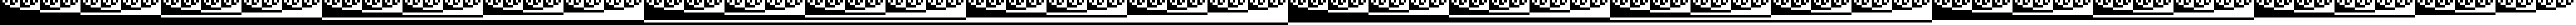

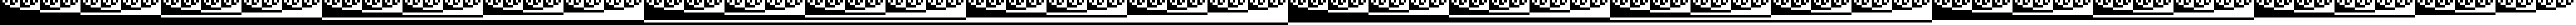

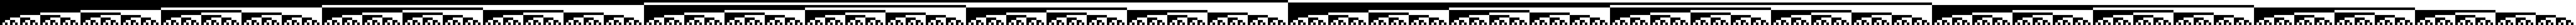

Data shape (1024, 10) | Train (896, 10) | Test (128, 10)


In [10]:
zoom_factor = 8


mid_point = x.shape[0] // 2
# plot_data = lambda x: np.concatenate([x[:128], x[-128:]], axis=0).T
# plot_data = lambda x: x.T
if x.shape[0] >= 1024:
    plot_data = lambda x: x[max(mid_point - 512, 0) : min(mid_point + 512, x.shape[0])].T
else:
    plot_data = lambda x: x.T

imshow(zoom(plot_data(x), zoom_factor))
imshow(zoom(plot_data(y0[:, ::-1]), zoom_factor))
imshow(zoom(plot_data(y0), zoom_factor))

print(f"Data shape {x.shape} | Train {x_train.shape} | Test {x_test.shape}")

In [11]:
x_text_reversed = plot_data(y0[:, ::-1]).T
y_text_reversed = plot_data(y0).T


## Backprop training

In [14]:
from boolean_nca_cc.training.evaluation import run_bp_scan

bp_eval_results = None

In [20]:
run_bp_eval = False

if run_bp_eval:
    opt = optax.adamw(1, 0.8, 0.8, weight_decay=1e-1)

    bp_eval_results = {
        damage_mode: run_bp_scan(
            # ── Engine ──
            opt=opt,
            batch_wires=pool.wires,
            batch_params=pool.logits,
            # ── Data ──
            x_data=x_train,
            y_data=y_train,
            x_test=x_test,
            y_test=y_test,
            # ── Params ──
            n_steps=n_steps,
            layer_sizes=layer_sizes,
            input_n=input_n,
            arity=arity,
            loss_cfg=LossConfig(loaded_config.loss),
            # ── Damage ──
            p_fault=damage_params["p_fault_eval"] if damage_mode == "probabilistic" else None,
            p_fault_onset_step=0,
            damage_mode=damage_mode,
            damage_steps=damage_steps,
            knockouts_per_event=damage_params["knockouts_per_event"],
            faulty_value=damage_params["faulty_logit_value"],
            permanent=0.5,
            compile=not force_cpu,
        )
        for damage_mode in damage_modes
    }

In [21]:
if run_bp_eval:
    plot_wandb_stepwise_results(
        bp_eval_results["deterministic"][1], title="BP Results: recoverable shotguns"
    )

    plt.show()


## Load Model

In [13]:
# Load model from config and checkpoint
best_attn_model, loaded_dict, init_attn_model = load_model_from_config_and_checkpoint(
    config=loaded_config,
    checkpoint_path=checkpoint_path,
    run_id=run_id,
    seed=loaded_config.seed,
    n_node=int(pool.graphs.n_node[0].item()),
)


2026-05-12 16:31:50,706 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_37mmnrgd/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-05-12 16:31:50,706 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_37mmnrgd/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-05-12 16:31:50,720 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-05-12 16:31:50,720 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format


2026-05-12 16:31:50,759 - boolean_nca_cc.training.checkpointing - INFO - Migrated legacy CircuitGatheredAttention checkpoint: re-nested ['attn_norm', 'attn_rezero', 'ffn', 'ffn_rezero', 'key_ln', 'key_proj', 'output_proj', 'query_ln', 'query_proj', 'value_proj'] under 'attn_block'.


Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 220}
Successfully instantiated model: CircuitGatheredAttention


In [14]:
from boolean_nca_cc.training.pool.structural_perturbation import (
    compute_p_fault_from_expected,
    count_eligible_gates,
)


In [15]:
damage_modes = ["none", "deterministic", "probabilistic"][:1]
damage_permanence = [0.5]
n_eligible_gates = count_eligible_gates(layer_sizes)
aim_failures = 0.15
n_steps = 512

n_damage_steps = 2
# shuffle_steps = [[n_steps // 2]]
shuffle_steps = [None]
damage_steps = jp.linspace(0, n_steps, n_damage_steps + 1, endpoint=False).astype(int)[1:]
knockouts_per_event = int(n_eligible_gates * aim_failures / n_damage_steps)

p_fault_onset_step = 32
p_fault_eval = compute_p_fault_from_expected(
    int(n_eligible_gates * aim_failures), n_eligible_gates, (n_steps - p_fault_onset_step)
)


print(
    f"Starting eval with {n_damage_steps} damage steps, {knockouts_per_event} knockouts per step | failure rate: {p_fault_eval:1e}"
)

attn_eval_results = {
    (
        tuple(shuffle_s) if shuffle_s is not None else None,
        damage_mode,
        permanent,
    ): evaluate_model_stepwise_batched(
        model=best_attn_model,
        batch_wires=pool.wires,
        batch_logits=pool.logits,
        x_data=x_train,
        # x_data=x_text_reversed,
        y_data=y_train,
        # y_data=y_text_reversed,
        input_n=input_n,
        n_message_steps=n_steps,
        arity=arity,
        circuit_hidden_dim=hidden_dim,
        loss_cfg=LossConfig(dict(loaded_config.loss)),
        layer_sizes=layer_sizes,
        damage_steps=damage_steps if damage_mode == "deterministic" else None,
        knockout_per_damage_step=knockouts_per_event if damage_mode == "deterministic" else None,
        p_fault=p_fault_eval if damage_mode == "probabilistic" else None,
        bidirectional_edges=True,
        permanent_damage=permanent,
        verbose=True,
        # No-repair baseline
        compute_no_repair_baseline=True,
        p_fault_onset_step=p_fault_onset_step,
        # Shuffle
        wire_shuffle_steps=shuffle_s,
        wire_shuffle_fraction=1.0,
    )
    for shuffle_s in shuffle_steps
    for damage_mode in damage_modes
    for permanent in damage_permanence
    if damage_mode != "none" or permanent != 1.0
}


Starting eval with 2 damage steps, 15 knockouts per step | failure rate: 3.385238e-04
Evaluation complete: 512 steps
  Loss: 1473.6331
  Accuracy: 0.9003
  Hard Acc: 0.9004


In [24]:
final_graph = jax.tree.map(lambda x: x[0], list(attn_eval_results.values())[0][0])

In [25]:
final_graph.nodes["logits"].shape

(220, 16)

In [26]:
from boolean_nca_cc.utils import (
    build_graph,
    extract_logits_from_graph,
)

final_logits = extract_logits_from_graph(final_graph, [l.shape[1:] for l in pool.logits])

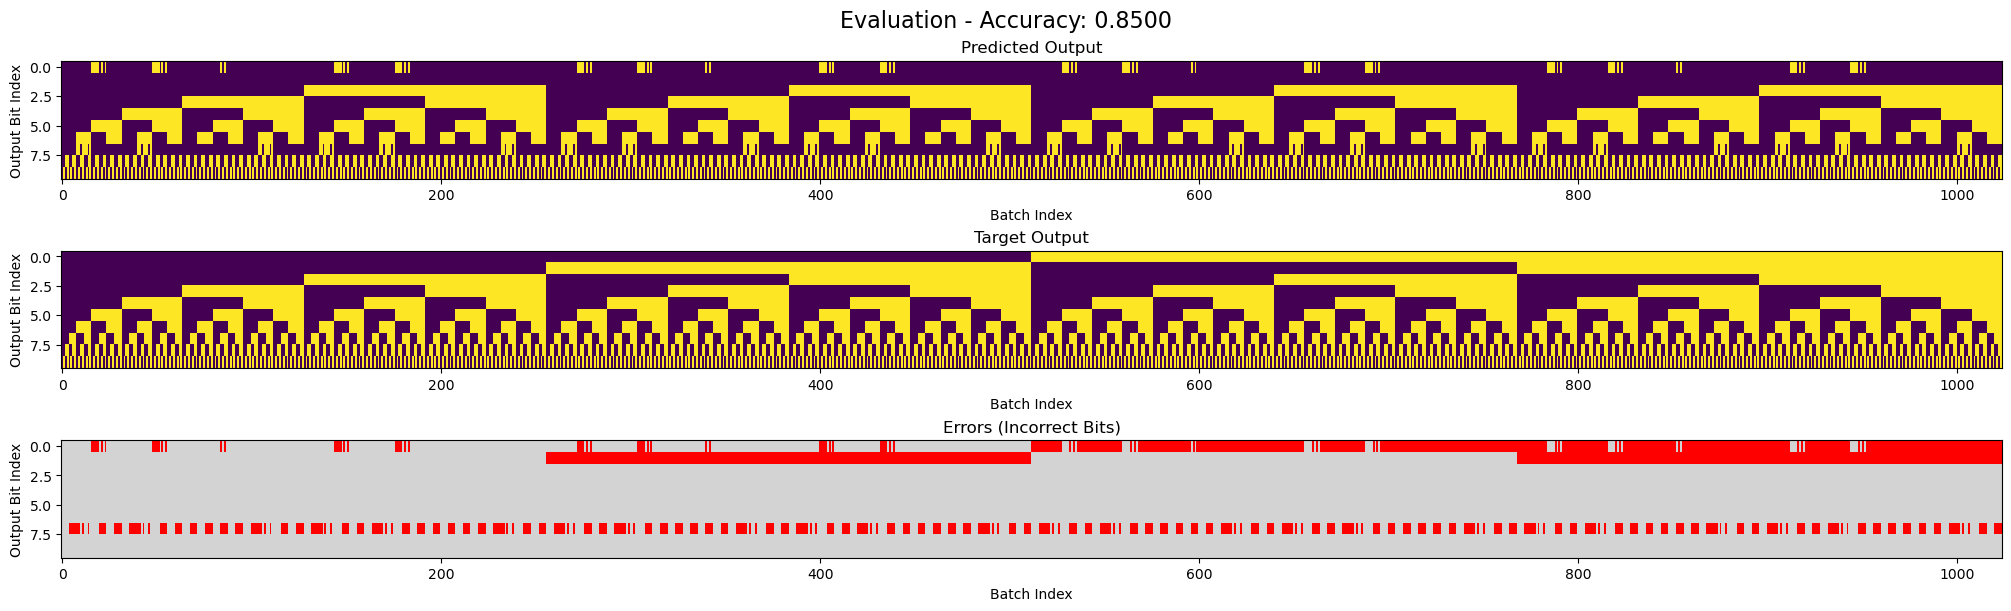

In [27]:
from boolean_nca_cc.circuits.viz import evaluate_and_visualize

metrics = evaluate_and_visualize(
    final_logits,
    jax.tree.map(lambda x: x[0], pool.wires),
    plot_data(x).T,
    plot_data(y0).T,
    hard=False,
)

In [32]:
# plot_wandb_stepwise_results(attn_eval_results[(None, "none", 0.5)][1], title="NCA Results: no damage, no suffle");

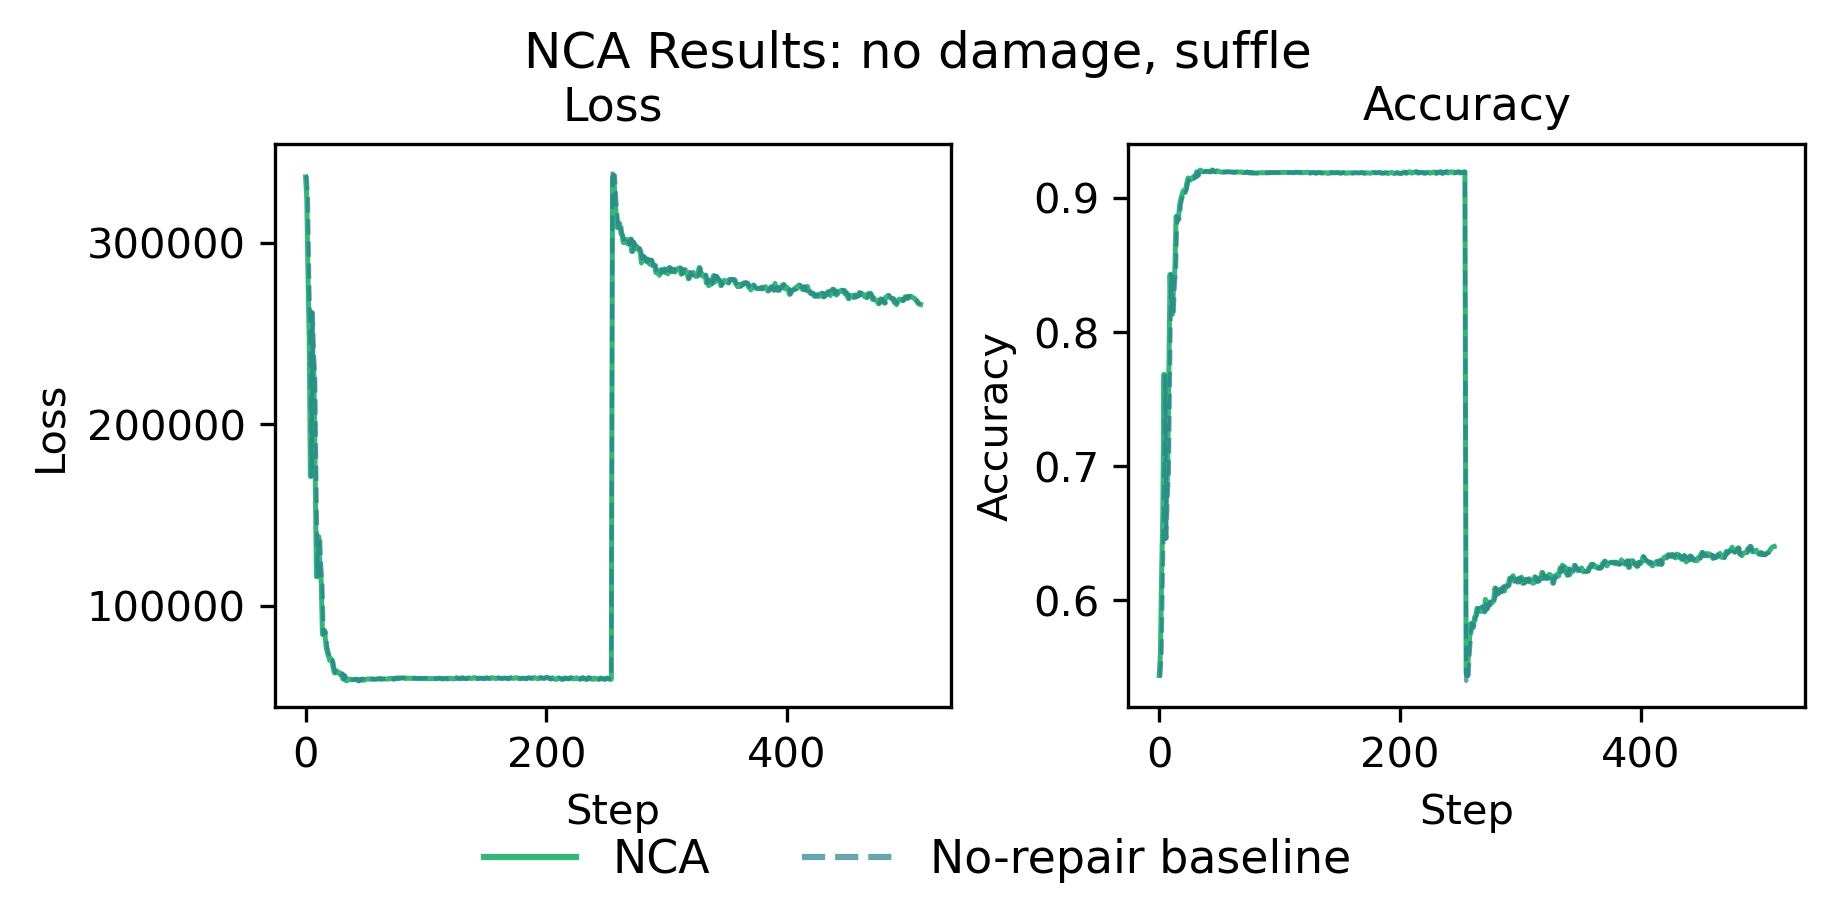

In [ ]:
plot_wandb_stepwise_results(
    attn_eval_results[(tuple(shuffle_steps[-1]), "none", 0.5)][1],
    title="NCA Results: no damage, suffle",
);

In [ ]:
raise KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
plot_wandb_stepwise_results(
    attn_eval_results[("deterministic", 0.5)][1], title="NCA Results: permanent shotguns"
)
plot_wandb_stepwise_results(
    attn_eval_results[("probabilistic", 0.5)][1],
    title="NCA Results: permanent stochastic failures",
)

plt.show()


KeyError: ('deterministic', 0.5)

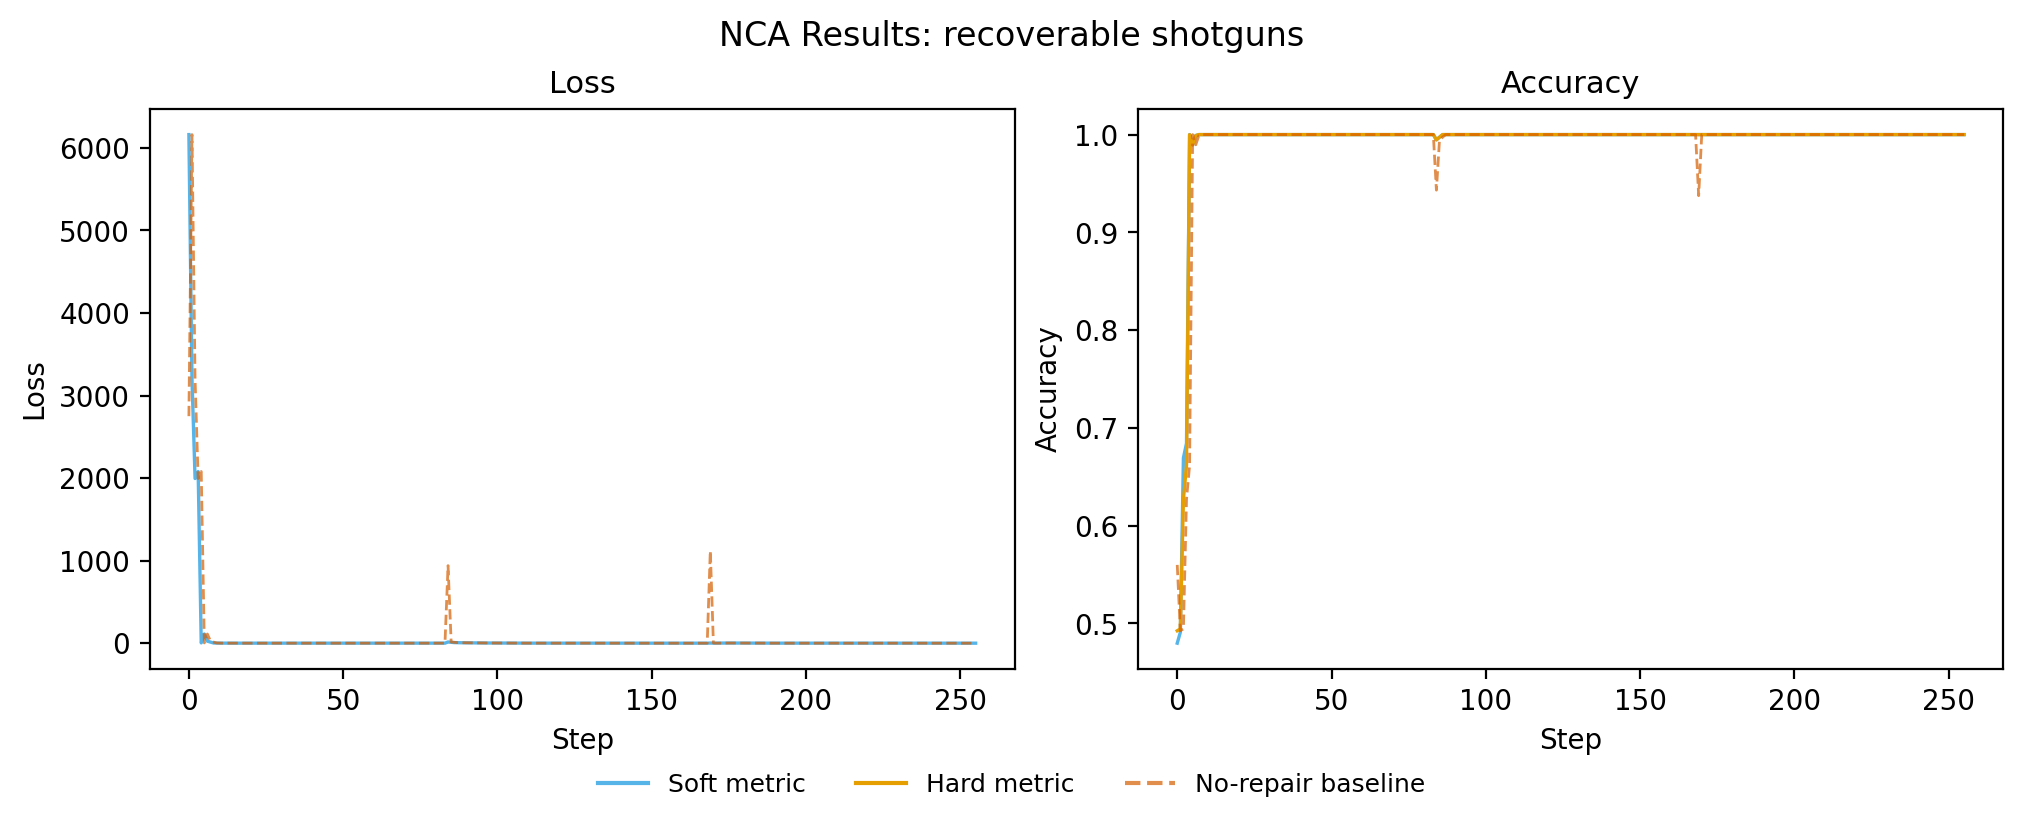

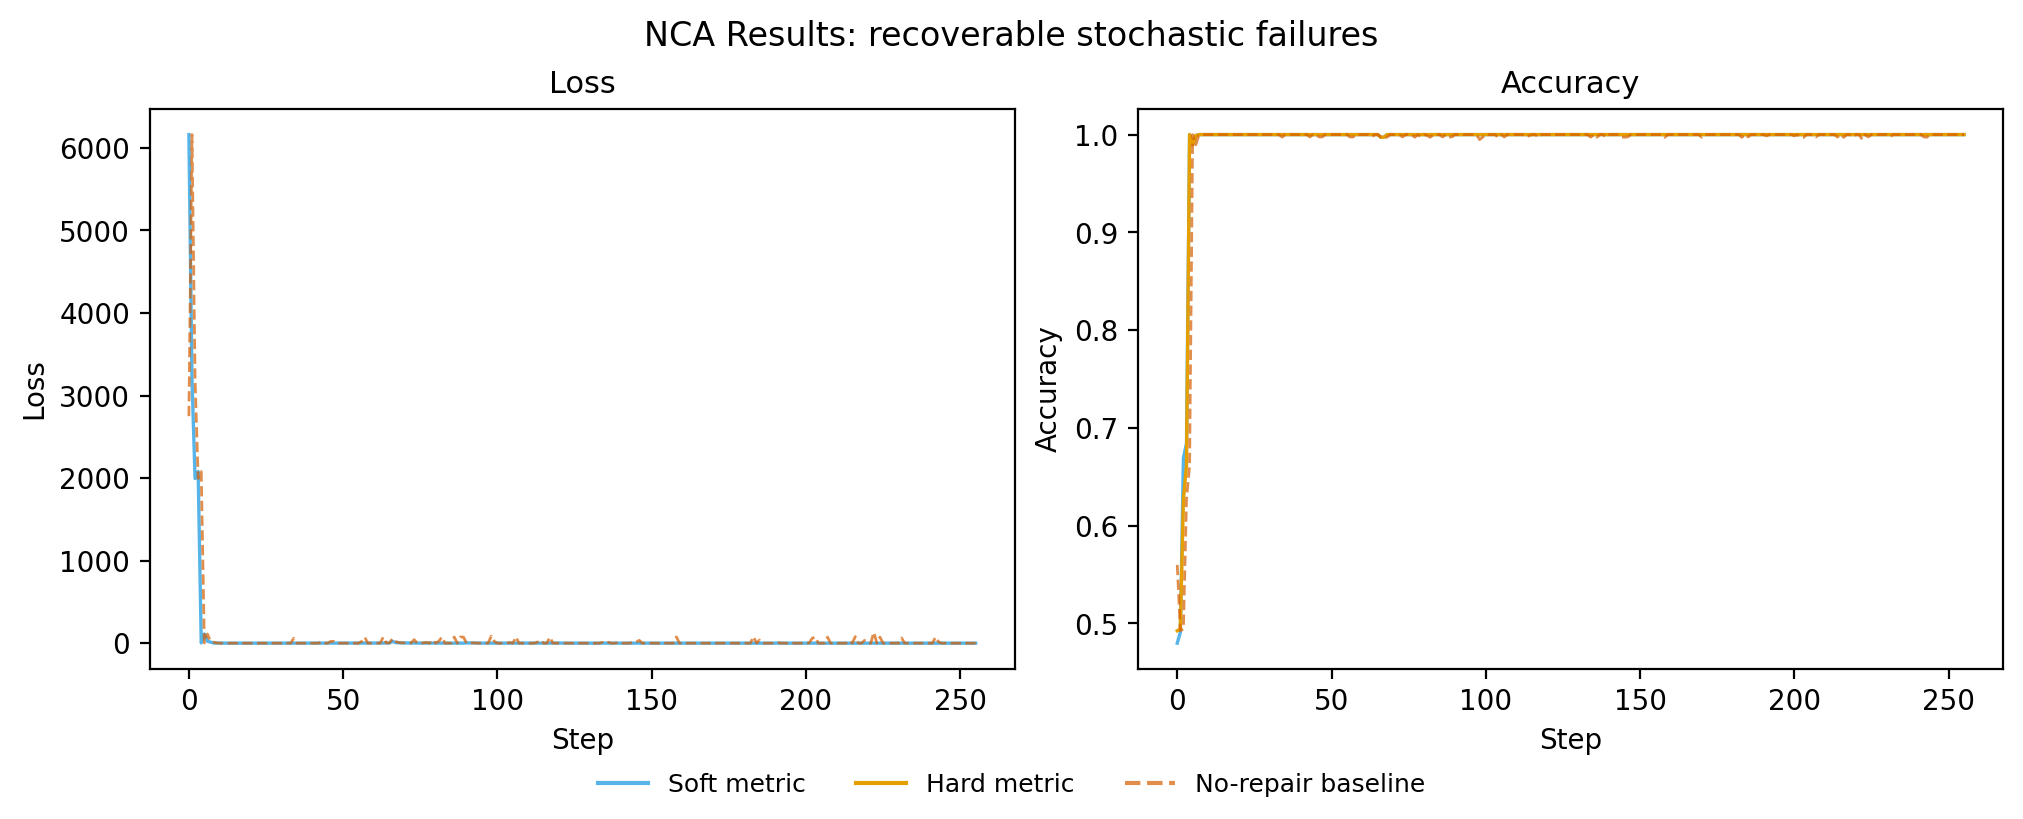

In [ ]:
plot_wandb_stepwise_results(
    attn_eval_results[("deterministic", 0.0)][1], title="NCA Results: recoverable shotguns"
)
plot_wandb_stepwise_results(
    attn_eval_results[("probabilistic", 0.0)][1],
    title="NCA Results: recoverable stochastic failures",
)

plt.show()


## PCA

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from umap import UMAP

# =====================================================================
# Build a single DataFrame with ALL trajectories + metadata
# =====================================================================


def build_trajectory_df(eval_results: dict, bp_results: dict | None = None) -> pd.DataFrame:
    """
    Build a tidy DataFrame from eval_results dict.

    eval_results: dict mapping (damage_mode, permanent) -> (final_graphs, step_metrics)

    Returns DataFrame with columns:
        batch, step, damage_mode, permanent, loss, hard_accuracy, + one col per logit feature
    """
    records = []

    for (damage_mode, permanent), (_, step_metrics) in tqdm(
        eval_results.items(),
        total=len(eval_results),
        desc="Building trajectory DataFrame from NCA results",
    ):
        logits_traj = np.array(step_metrics["graphs"].nodes["logits"])
        batch_size, n_steps, _, _ = logits_traj.shape

        # Flatten nodes*logits -> single feature vector per (batch, step)
        logits_flat = logits_traj.reshape(batch_size, n_steps, -1)

        # Per-step metrics (batch-averaged)
        # losses = np.array(step_metrics["loss"])  # (n_steps,)
        # hard_accs = np.array(step_metrics["hard_accuracy"])  # (n_steps,)

        for b in range(batch_size):
            for t in range(n_steps):
                records.append(
                    {
                        "batch": b,
                        "step": t,
                        "damage_mode": damage_mode,
                        "permanent": permanent,
                        "logits_vec": logits_flat[b, t],  # np array, will extract later
                        "model": "NCA",
                    }
                )
                records[-1].update(
                    {
                        metric: step_metrics["all_metrics"][metric][b, t].item()
                        for metric in step_metrics["all_metrics"]
                    }
                )

    if bp_results is not None:
        for (damage_mode, permanent), (_, bp_step_metrics) in tqdm(
            bp_results.items(),
            total=len(bp_results),
            desc="Building trajectory DataFrame from BP results",
        ):
            for b in range(batch_size):
                for t in range(n_steps):
                    records.append(
                        {
                            "model": "BP",
                            "batch": b,
                            "step": t,
                            "damage_mode": damage_mode,
                            "permanent": permanent,
                            "logits_vec": bp_step_metrics["graphs"]
                            .nodes["logits"][b, t]
                            .reshape(-1),
                        }
                    )
                    records[-1].update(
                        {
                            metric: bp_step_metrics["all_metrics"][metric][b, t].item()
                            for metric in bp_step_metrics["all_metrics"]
                        }
                    )

    df = pd.DataFrame(records)
    return df


def add_pca_columns(
    df: pd.DataFrame, n_components: int = 2, scale: bool = True, use_sigmoid: bool = True
) -> pd.DataFrame:
    """
    Fit PCA on ALL logit vectors jointly, add PC1/PC2/... columns to df.
    Returns df with new columns + the fitted PCA and scaler objects.
    """
    pca_df = df.copy()
    X = (
        np.stack(pca_df["logits_vec_sigmoid"].values)
        if "logits_vec_sigmoid" in pca_df.columns and use_sigmoid
        else np.stack(pca_df["logits_vec"].values)
    )  # (n_total, feature_dim)

    scaler = StandardScaler() if scale else None
    X_scaled = scaler.fit_transform(X) if scale else X

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    for i in range(n_components):
        pca_df[f"PC{i + 1}"] = X_pca[:, i]

    print(f"PCA on {X.shape[0]} points, feature_dim={X.shape[1]}")
    print(f"Explained variance: {pca.explained_variance_ratio_}")
    print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

    return pca_df, pca, scaler


def add_umap_columns(
    df: pd.DataFrame, n_components: int = 2, scale: bool = True, umap_kwargs: dict = None
):
    """
    Fit UMAP on ALL logit vectors jointly, add UMAP1/UMAP2/... columns to df.

    Key: use PCA pre-reduction + PCA init to preserve trajectory smoothness.
    """
    import umap

    X = np.stack(df["logits_vec"].values)

    scaler = StandardScaler() if scale else None
    X_scaled = scaler.fit_transform(X) if scale else X

    # Step 1: PCA pre-reduction to ~30 dims removes noise,
    # makes UMAP's distance computations much more meaningful
    pca_pre = PCA(n_components=min(30, X_scaled.shape[1]))
    X_pca = pca_pre.fit_transform(X_scaled)
    print(
        f"PCA pre-reduction: {X_scaled.shape[1]} -> {X_pca.shape[1]} dims "
        f"({pca_pre.explained_variance_ratio_.sum():.1%} variance retained)"
    )

    defaults = {
        "n_components": n_components,
        "n_neighbors": 50,  # higher = more global structure preserved
        "min_dist": 0.3,  # higher = less clumping, smoother trajectories
        "metric": "euclidean",
        "init": "spectral",  # spectral init respects global geometry
        "random_state": 42,
    }
    if umap_kwargs:
        defaults.update(umap_kwargs)

    reducer = umap.UMAP(**defaults)
    X_umap = reducer.fit_transform(X_pca)  # fit on PCA-reduced, not raw

    for i in range(n_components):
        df[f"UMAP{i + 1}"] = X_umap[:, i]

    print(f"UMAP on {X_pca.shape[0]} points, input_dim={X_pca.shape[1]}")
    return df, reducer, scaler


In [ ]:
import jax
import jax.numpy as jp
import numpy as np
import optax
from jax import grad, jit, value_and_grad


def refine_embedding_temporal(
    Y_init: np.ndarray,
    trajectory_groups: list[np.ndarray],
    mu_attract: float = 5.0,  # Pull consecutive points together
    lambda_smooth: float = 2.0,  # Penalise sharp turns (Laplacian smoothness)
    lambda_fidelity: float = 1.0,  # Anchor to original embedding
    n_iter: int = 500,
    lr: float = 1e-2,
    verbose: bool = True,
):
    """
    Refine a 2D/ND embedding with temporal smoothness.

    Uses squared distances & Laplacian smoothness — no sqrt, no epsilon,
    no division by edge length.  Gradients are clean and well-conditioned.

    Losses:
      - Attraction:  mean( ||y_{t+1} - y_t||² )          [consecutive proximity]
      - Smoothness:  mean( ||y_{t+1} - 2y_t + y_{t-1}||² ) [penalise curvature]
      - Fidelity:    mean( ||y - y_0||² )                 [anchor to PCA]
    """
    N, D = Y_init.shape

    # Normalize to unit std per dimension
    mu = Y_init.mean(axis=0)
    std = Y_init.std(axis=0) + 1e-8
    Y0 = jp.array((Y_init - mu) / std, dtype=jp.float32)

    # Build edge & triple indices
    src_list, dst_list = [], []
    prev_list, mid_list, nxt_list = [], [], []
    for traj in trajectory_groups:
        traj = np.asarray(traj)
        if len(traj) < 2:
            continue
        src_list.append(traj[:-1])
        dst_list.append(traj[1:])
        if len(traj) >= 3:
            prev_list.append(traj[:-2])
            mid_list.append(traj[1:-1])
            nxt_list.append(traj[2:])

    src = jp.array(np.concatenate(src_list))
    dst = jp.array(np.concatenate(dst_list))
    prev = jp.array(np.concatenate(prev_list))
    mid = jp.array(np.concatenate(mid_list))
    nxt = jp.array(np.concatenate(nxt_list))

    if verbose:
        # Diagnostic: actual edge length stats in normalized space
        diffs_np = np.array(Y0[dst] - Y0[src])
        sq_lens = np.sum(diffs_np**2, axis=1)
        real_lens = np.sqrt(sq_lens)
        print(
            f"  Normalized edge lengths: "
            f"min={real_lens.min():.2e}, median={np.median(real_lens):.2e}, "
            f"max={real_lens.max():.2e}, mean={real_lens.mean():.2e}"
        )
        print(f"  Edges: {len(src)}, Triples: {len(prev)}")

    @jit
    def loss_fn(Y):
        # 1. Fidelity: anchor to PCA (no sqrt needed)
        fidelity = jp.mean(jp.sum((Y - Y0) ** 2, axis=1))

        # 2. Attraction: pull consecutive points together (squared distance, no sqrt!)
        diffs = Y[dst] - Y[src]
        attract = jp.mean(jp.sum(diffs**2, axis=1))

        # 3. Laplacian smoothness: penalise curvature / sharp turns
        #    second discrete derivative: y_{t+1} - 2*y_t + y_{t-1}
        #    = 0 for straight lines, large for sharp turns
        laplacian = Y[nxt] - 2.0 * Y[mid] + Y[prev]
        smooth = jp.mean(jp.sum(laplacian**2, axis=1))

        total = lambda_fidelity * fidelity + mu_attract * attract + lambda_smooth * smooth
        return total, (fidelity, attract, smooth)

    @jit
    def step(Y, opt_state):
        (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(Y)
        updates, new_opt_state = optimizer.update(grads, opt_state, Y)
        Y_new = optax.apply_updates(Y, updates)
        return Y_new, new_opt_state, loss, aux

    optimizer = optax.adam(lr)
    Y = Y0.copy()
    opt_state = optimizer.init(Y)

    if verbose:
        _, (f0, a0, s0) = loss_fn(Y)
        print(
            f"  Initial — fidelity: {float(f0):.2e}, attract: {float(a0):.2e}, smooth: {float(s0):.2e}"
        )
        print(
            f"  Weights — fidelity: {lambda_fidelity}, attract: {mu_attract}, smooth: {lambda_smooth}"
        )
        grad_norm = float(jp.sqrt(jp.sum(jax.grad(lambda Y: loss_fn(Y)[0])(Y) ** 2)))
        print(f"  Initial gradient norm: {grad_norm:.2e}")

    losses = []
    for i in range(n_iter):
        Y, opt_state, loss_val, (fid, att, smo) = step(Y, opt_state)
        if verbose and (i % 100 == 0 or i == n_iter - 1):
            l = float(loss_val)
            losses.append(l)
            print(
                f"  iter {i:4d}/{n_iter}: loss={l:.2e}  "
                f"(fid={float(fid):.2e}, attract={float(att):.2e}, smooth={float(smo):.2e})"
            )

    # De-normalize
    Y_out = np.array(Y) * std + mu
    return Y_out, losses


def add_temporally_refined_pca_columns(
    df,
    n_components=2,
    scale=True,
    use_sigmoid=False,
    # temporal refinement params
    mu_ell=1.0,
    alpha_ell=1.5,
    lambda_dcl=0.5,
    lambda_fidelity=0.1,
    n_iter=500,
    lr=1e-2,
    verbose=True,
):
    """
    PCA + temporal refinement in one step.

    1. Runs joint PCA on all logit vectors
    2. Refines the embedding with ELL + continuation-angle smoothness
    3. Adds PC1_t, PC2_t columns (temporally refined) alongside PC1, PC2 (raw PCA)
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    out_df = df.copy()

    # ── Step 1: Standard PCA ────────────────────────────────────
    col = (
        "logits_vec_sigmoid"
        if ("logits_vec_sigmoid" in out_df.columns and use_sigmoid)
        else "logits_vec"
    )
    X = np.stack(out_df[col].values)

    scaler = StandardScaler() if scale else None
    X_s = scaler.fit_transform(X) if scale else X

    pca = PCA(n_components=n_components)
    Y_pca = pca.fit_transform(X_s)

    for i in range(n_components):
        out_df[f"PC{i + 1}"] = Y_pca[:, i]

    if verbose:
        print(f"PCA: {X.shape[0]} pts, {X.shape[1]} features → {n_components}D")
        print(f"  Explained variance: {pca.explained_variance_ratio_}")
        print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

    # ── Step 2: Build trajectory groups ─────────────────────────
    group_cols = [c for c in ["model", "batch", "damage_mode", "permanent"] if c in out_df.columns]
    trajectory_groups = []
    for _, grp in out_df.groupby(group_cols, sort=False):
        sorted_grp = grp.sort_values("step")
        trajectory_groups.append(sorted_grp.index.values)

    if verbose:
        print(f"  {len(trajectory_groups)} trajectories detected")

    # ── Step 3: Temporal refinement ─────────────────────────────
    if verbose:
        print("Refining with ELL + continuation-angle smoothness…")

    Y_refined, losses = refine_embedding_temporal(
        Y_pca,
        trajectory_groups,
        verbose=verbose,
    )

    for i in range(n_components):
        out_df[f"PC{i + 1}_t"] = Y_refined[:, i]

    return out_df, pca, scaler


In [ ]:
# --- Build it ---
traj_df = build_trajectory_df(attn_eval_results, bp_results=None)

Building trajectory DataFrame from NCA results:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
traj_df["logits_vec_sigmoid"] = traj_df["logits_vec"].apply(lambda x: jax.nn.sigmoid(x))


In [ ]:
models_to_use = ["NCA"]

use_temporal_refinement = False
use_umap = False
use_sigmoid = False

if not use_temporal_refinement:
    traj_df_pca, pca, scaler = add_pca_columns(
        traj_df.query(f"model in {models_to_use}"), n_components=4, use_sigmoid=use_sigmoid
    )
else:
    traj_df_pca, pca, scaler = add_temporally_refined_pca_columns(
        df=traj_df.query(f"model in {models_to_use}"),
        n_iter=500,
        use_sigmoid=use_sigmoid,
    )


if use_umap:
    traj_df_pca, umap, scaler = add_umap_columns(traj_df_pca, n_components=4)

# Drop the heavy logits_vec column now that we have PCs
traj_df_pca = traj_df_pca.drop(columns=["logits_vec"])

# Make nice labels
traj_df_pca["damage_label"] = traj_df_pca["damage_mode"].replace(
    {
        "none": "No damage",
        "probabilistic": "Stochastic failures",
        "deterministic": "Shotgun failures",
    }
)

traj_df_pca["permanent_label"] = traj_df_pca["permanent"].map(
    {1.0: "Permanent", 0.0: "Recoverable"}
)
traj_df_pca["condition"] = traj_df_pca["damage_label"] + "\n" + traj_df_pca["permanent_label"]

print(f"\nDataFrame shape: {traj_df_pca.shape}")
print(f"Conditions: {traj_df_pca.groupby(['damage_mode', 'permanent']).size()}")
traj_df_pca.head()


PCA on 20480 points, feature_dim=4224
Explained variance: [0.7394111  0.02274367 0.01374564 0.01059974]
Total explained: 78.65%

DataFrame shape: (20480, 17)
Conditions: damage_mode    permanent
deterministic  0.0          4096
               1.0          4096
none           0.0          4096
probabilistic  0.0          4096
               1.0          4096
dtype: int64


,batch,step,damage_mode,permanent,model,loss,hard_loss,accuracy,hard_accuracy,logits_vec_sigmoid,PC1,PC2,PC3,PC4,damage_label,permanent_label,condition
0,0,0,none,0.0,NCA,6160.586914,24869.636719,0.479818,0.492513,"[0.99919873, 0.99989665, 0.8194777, 0.10706567...",104.260223,-17.824503,18.314177,-1.182588,No damage,Recoverable,No damage\nRecoverable
1,0,1,none,0.0,NCA,3201.610596,24791.207031,0.490885,0.494466,"[0.7092307, 0.0074033155, 1.172253e-06, 0.0007...",103.210335,-18.479921,15.327858,-1.024412,No damage,Recoverable,No damage\nRecoverable
2,0,2,none,0.0,NCA,1994.588867,18358.523438,0.669271,0.626953,"[0.28391308, 3.0038145e-05, 1.4539413e-17, 1.4...",101.513847,-18.460300,14.477298,-1.041480,No damage,Recoverable,No damage\nRecoverable
3,0,3,none,0.0,NCA,2079.311035,16652.462891,0.684245,0.661458,"[0.87315327, 4.1170996e-09, 4.087553e-17, 1.05...",101.799942,-17.399448,15.058218,-1.276454,No damage,Recoverable,No damage\nRecoverable
4,0,4,none,0.0,NCA,3.462691,0.000366,1.000000,1.000000,"[0.44063678, 1.6314304e-07, 2.5317848e-30, 2.3...",98.139915,-14.479157,14.532454,-1.532478,No damage,Recoverable,No damage\nRecoverable


In [ ]:
# Quick diagnostic: what do edge lengths actually look like?
Y_pca = np.column_stack([traj_df_pca["PC1"].values, traj_df_pca["PC2"].values])
group_cols = [c for c in ["model", "batch", "damage_mode", "permanent"] if c in traj_df_pca.columns]
edge_lengths = []
for _, grp in traj_df_pca.groupby(group_cols, sort=False):
    sorted_grp = grp.sort_values("step")
    idx = sorted_grp.index.values
    Y_traj = np.column_stack([sorted_grp["PC1"].values, sorted_grp["PC2"].values])

    diffs = np.diff(Y_traj, axis=0)
    lens = np.linalg.norm(diffs, axis=1)
    edge_lengths.extend(lens)

edge_lengths = np.array(edge_lengths)

print(
    f"PCA coordinate range: PC1=[{Y_pca[:, 0].min():.1f}, {Y_pca[:, 0].max():.1f}], "
    f"PC2=[{Y_pca[:, 1].min():.1f}, {Y_pca[:, 1].max():.1f}]"
)
print(
    f"Edge lengths: min={edge_lengths.min():.6f}, median={np.median(edge_lengths):.6f}, "
    f"max={edge_lengths.max():.6f}, mean={edge_lengths.mean():.6f}"
)
print(f"Total trajectory length (mean): {edge_lengths.reshape(80, -1).sum(axis=1).mean():.2f}")
print(f"Embedding span: {np.ptp(Y_pca[:, 0]):.2f} x {np.ptp(Y_pca[:, 1]):.2f}")
print(
    f"Edge/span ratio: {np.median(edge_lengths) / max(np.ptp(Y_pca[:, 0]), np.ptp(Y_pca[:, 1])):.6f}"
)


PCA coordinate range: PC1=[-107.6, 104.3], PC2=[-40.6, 11.4]
Edge lengths: min=0.015771, median=0.823246, max=10.058505, mean=0.864101
Total trajectory length (mean): 220.35
Embedding span: 211.84 x 51.95
Edge/span ratio: 0.003886


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =====================================================================
# Helper: replace seaborn legend with a colorbar
# =====================================================================


def legend_to_colorbar(g, hue_col, data, palette="viridis", label=None, vmin=None, vmax=None):
    """
    Remove seaborn's auto-legend from a FacetGrid/relplot and
    replace it with a single colorbar on the right side.

    Parameters
    ----------
    g : sns.FacetGrid (returned by relplot, FacetGrid, etc.)
    hue_col : str, column name used as hue
    data : DataFrame that was plotted
    palette : str, colormap name
    label : str, colorbar label (defaults to hue_col)
    """
    # Remove the legend seaborn created
    if g.legend is not None:
        g.legend.remove()
    # Also try the _legend attribute (relplot stores it there)
    if hasattr(g, "_legend") and g._legend is not None:
        g._legend.remove()

    vmin = data[hue_col].min() if vmin is None else vmin
    vmax = data[hue_col].max() if vmax is None else vmax

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])

    # Add colorbar to the figure, stealing space from the right
    g.figure.subplots_adjust(right=0.9)
    cbar_ax = g.figure.add_axes([0.94, 0.2, 0.015, 0.5])  # [left, bottom, width, height]
    cbar = g.figure.colorbar(sm, cax=cbar_ax)
    cbar.set_label(label or hue_col, fontsize=11)

    return g


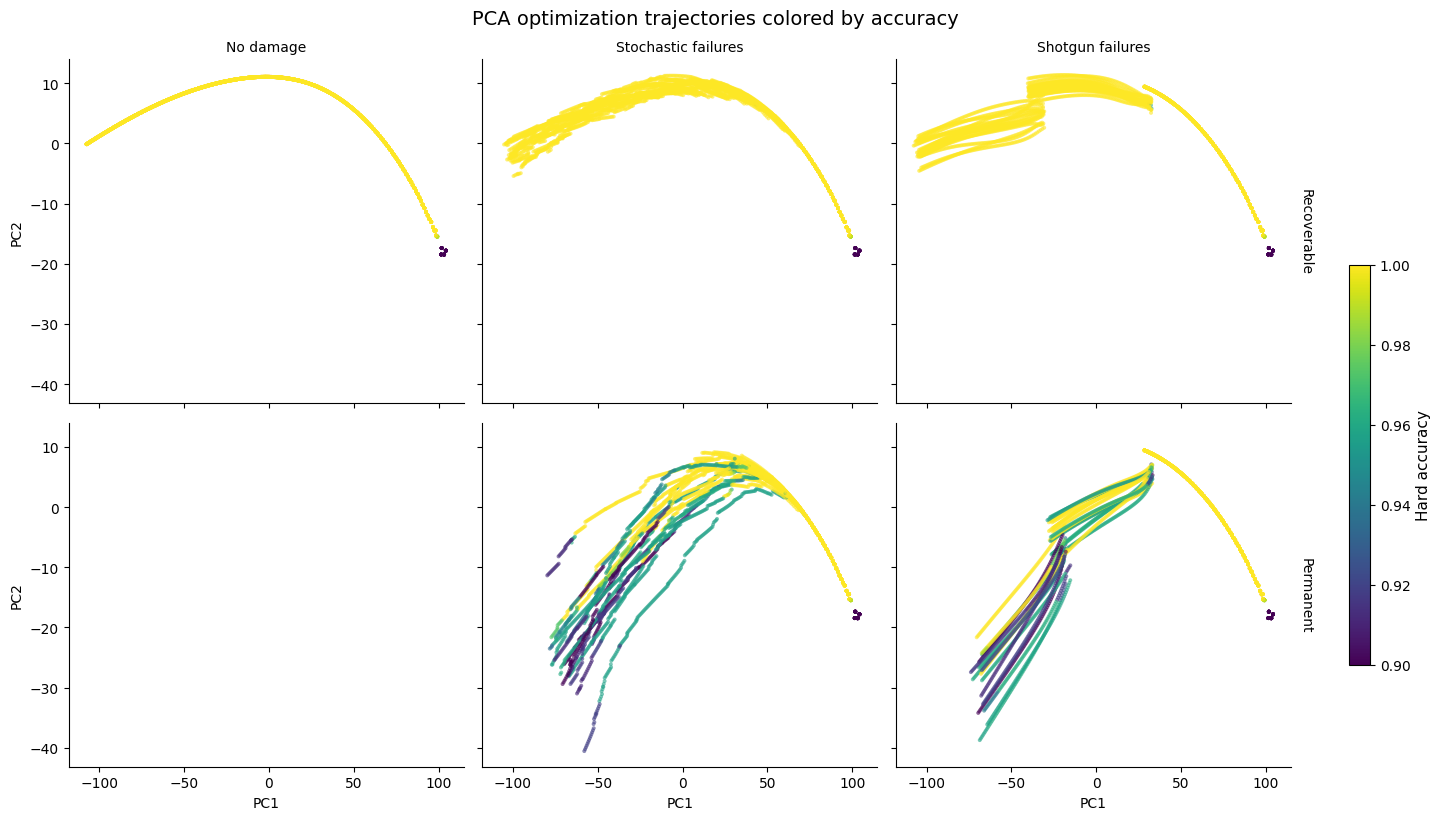

In [ ]:
v_min, v_max = 0.9, 1.0
hue_norm = mcolors.LogNorm(vmin=v_min, vmax=v_max)
hue = "hard_accuracy"

use_umap = False

g = sns.relplot(
    data=traj_df_pca,
    x="PC1" if not use_umap else "UMAP1",
    y="PC2" if not use_umap else "UMAP2",
    hue=hue,
    style="model",
    col="damage_label",
    row="permanent_label",
    palette="viridis",
    kind="scatter",
    s=8,
    alpha=0.6,
    edgecolor="none",
    facet_kws={"sharex": True, "sharey": True, "margin_titles": True},
    height=4,
    aspect=1.2,
    legend=False,
    hue_norm=hue_norm if hue == "hard_accuracy" else None,
    row_order=["Recoverable", "Permanent"],
)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.figure.suptitle("PCA optimization trajectories colored by accuracy", y=1.02, fontsize=14)
legend_to_colorbar(
    g,
    hue,
    traj_df_pca,
    palette="viridis",
    label=hue.replace("_", " ").capitalize(),
    vmin=v_min if "accuracy" in hue else None,
    vmax=v_max if "accuracy" in hue else None,
)

# new_bbox = (bbox.x0, bbox.y0 - 0.25, bbox.width, bbox.height)
# fig.axes[0].set_position(new_bbox)
# fig.delaxes(fig.axes[3])
plt.show()


/tmp/ipykernel_745053/4083620673.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20")


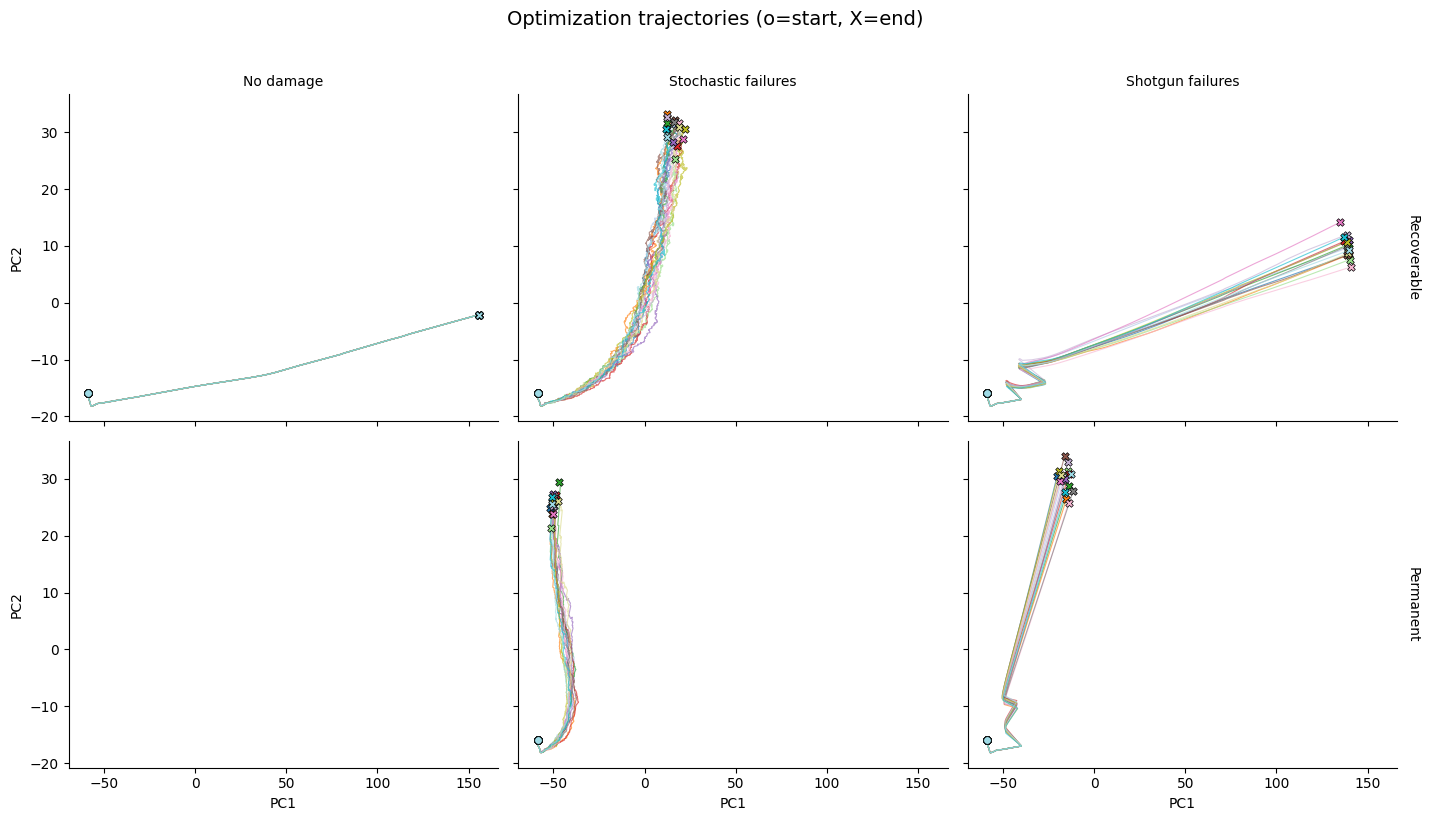

In [ ]:
# =====================================================================
# Trajectory LINES per batch, faceted by condition
# (seaborn FacetGrid + matplotlib line drawing)
# =====================================================================


def draw_trajectory_lines(data, x="PC1", y="PC2", **kwargs):
    """Map function for FacetGrid: draw one line per batch."""
    ax = plt.gca()
    color_map = plt.cm.get_cmap("tab20")
    batches = data["batch"].unique()
    models = data["model"].unique()
    linestyles = {"NCA": "-", "BP": "--"}

    for m in models:
        for b in batches:
            sub = data[(data["batch"] == b) & (data["model"] == m)].sort_values("step")
            c = color_map(b / max(batches.max(), 1))
            ax.plot(
                sub[x].values, sub[y].values, color=c, alpha=0.65, lw=0.8, linestyle=linestyles[m]
            )

            # Start marker
            ax.scatter(
                sub[x].iloc[0],
                sub[y].iloc[0],
                color=c,
                s=30,
                marker="o",
                edgecolors="k",
                linewidths=0.5,
                zorder=5,
            )
            # End marker
            ax.scatter(
                sub[x].iloc[-1],
                sub[y].iloc[-1],
                color=c,
                s=30,
                marker="X",
                edgecolors="k",
                linewidths=0.5,
                zorder=5,
            )


g = sns.FacetGrid(
    traj_df_pca,
    col="damage_label",
    row="permanent_label",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=4,
    aspect=1.2,
)
g.map_dataframe(draw_trajectory_lines)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("PC1", "PC2")
g.figure.suptitle("Optimization trajectories (o=start, X=end)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
raise KeyboardInterrupt("Stop here")

KeyboardInterrupt: Stop here

## Scale-free experiments

In [ ]:
# run_id = "gbena/boolean-nca-cc/xdxlabd2"  # Fixed wires, damages, reverse task
# run_id = "gbena/boolean-nca-cc/yu6kojmx"  # Fixed wires, damages, reverse task
run_id = "gbena/boolean-nca-cc/f1vzpb58"  # Random wires, damages, reverse task

loaded_config, checkpoint_path, run_id = load_config_from_wandb(
    run_id=run_id.split("/")[-1],
    entity="gbena",
    filename="eval_damaged",
    use_cache=False,
    # filename="latest_checkpoint",
)


2026-02-11 21:29:03,030 - boolean_nca_cc.training.checkpointing - INFO - Looking for run with ID: f1vzpb58
2026-02-11 21:29:03,363 - boolean_nca_cc.training.checkpointing - INFO - Found run: scarlet-fire-950
2026-02-11 21:29:03,364 - boolean_nca_cc.training.checkpointing - INFO - Checking for local checkpoint at: saves/run_f1vzpb58/eval_damaged.pkl
2026-02-11 21:29:03,364 - boolean_nca_cc.training.checkpointing - INFO - Cache disabled, downloading from WandB.
2026-02-11 21:29:03,364 - boolean_nca_cc.training.checkpointing - INFO - Retrieving artifacts...
2026-02-11 21:29:03,475 - boolean_nca_cc.training.checkpointing - INFO - Available artifacts:
2026-02-11 21:29:04,461 - boolean_nca_cc.training.checkpointing - INFO -   - run-f1vzpb58-poolscatter_steps_vs_loss_table-cxzcGQ:v0
2026-02-11 21:29:04,462 - boolean_nca_cc.training.checkpointing - INFO -   - run-f1vzpb58-poolscatter_damage_vs_loss_table-zmIlZw:v0
2026-02-11 21:29:04,462 - boolean_nca_cc.training.checkpointing - INFO -   - bes

In [ ]:
case_n = 2**loaded_config.circuit.input_bits
base_key = jax.random.PRNGKey(loaded_config.seed)
eval_key = jax.random.fold_in(base_key, 1)
hidden_dim = loaded_config.circuit.circuit_hidden_dim
n_message_steps = loaded_config.training.n_message_steps
input_n, output_n = loaded_config.circuit.input_bits, loaded_config.circuit.output_bits
arity = loaded_config.circuit.arity


layer_widths = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]

layer_sizes = {
    width_factor: generate_layer_sizes(
        input_n,
        output_n,
        arity,
        layer_n=loaded_config.circuit.num_layers,
        width_factor=width_factor,
    )
    for width_factor in layer_widths
}

if loaded_config.training.wiring_mode == "fixed":
    pool_key = eval_key
else:
    pool_key = jax.random.fold_in(eval_key, 1)

wires_key, logits_key = jax.random.split(pool_key, 2)

batch_size = 16

pools = {
    width_factor: initialize_graph_pool(
        wires_key=wires_key,
        logits_key=logits_key,
        pool_size=batch_size,
        layer_sizes=layer_sizes[width_factor],
        arity=arity,
        input_n=input_n,
        circuit_hidden_dim=hidden_dim,
        wiring_mode=loaded_config.training.wiring_mode,
        # noise_scale=loaded_config.pool.noise_scale,
        noise_scale=0.1,
    )
    for width_factor in layer_widths
}

damage_params = compute_damage_params(
    loaded_config, layer_sizes[loaded_config.circuit.width_factor], None
)


In [ ]:
# Load model from config and checkpoint
best_attn_models = {
    key: load_model_from_config_and_checkpoint(
        config=loaded_config,
        checkpoint_path=checkpoint_path,
        run_id=run_id,
        seed=loaded_config.seed,
        n_node=int(pool.graphs.n_node[0].item()),
    )[0]
    for key, pool in pools.items()
}


2026-02-11 21:32:31,711 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,712 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,718 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-11 21:32:31,718 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format
2026-02-11 21:32:31,738 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,738 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,744 - boolean_nca_cc

2026-02-11 21:32:31,785 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,785 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,791 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-11 21:32:31,791 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format
2026-02-11 21:32:31,808 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,809 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-11 21:32:31,814 - boolean_nca_cc

Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 168}
Successfully instantiated model: CircuitGatheredAttention
Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 216}
Successfully instantiated model: CircuitGatheredAttention
Instan

In [ ]:
attn_eval_results = {
    (key, damage): evaluate_model_stepwise_batched(
        model=best_attn_models[key],
        batch_wires=pools[key].wires,
        batch_logits=pools[key].logits,
        x_data=x_test,
        y_data=y_test,
        input_n=input_n,
        n_message_steps=256,
        arity=arity,
        circuit_hidden_dim=hidden_dim,
        loss_cfg=LossConfig(dict(loaded_config.loss)),
        layer_sizes=layer_sizes[key],
        damage_steps=None,
        knockout_per_damage_step=None,
        p_fault=damage_params["p_fault_eval"] if damage else None,
        bidirectional_edges=True,
        permanent_damage=True,
        verbose=True,
        # No-repair baseline
        compute_no_repair_baseline=False,
        p_fault_onset_step=0,
    )
    for key in pools
    for damage in [True, False]
}


Evaluation complete: 256 steps
  Loss: 1489.4666
  Accuracy: 0.7160
  Hard Acc: 0.7119
Evaluation complete: 256 steps
  Loss: 1271.0208
  Accuracy: 0.7653
  Hard Acc: 0.7638
Evaluation complete: 256 steps
  Loss: 1173.0117
  Accuracy: 0.7875
  Hard Acc: 0.7876
Evaluation complete: 256 steps
  Loss: 925.0096
  Accuracy: 0.8284
  Hard Acc: 0.8274
Evaluation complete: 256 steps
  Loss: 874.5975
  Accuracy: 0.8345
  Hard Acc: 0.8349
Evaluation complete: 256 steps
  Loss: 628.2374
  Accuracy: 0.8826
  Hard Acc: 0.8825
Evaluation complete: 256 steps
  Loss: 744.5253
  Accuracy: 0.8569
  Hard Acc: 0.8532
Evaluation complete: 256 steps
  Loss: 466.8466
  Accuracy: 0.9148
  Hard Acc: 0.9142
Evaluation complete: 256 steps
  Loss: 769.0739
  Accuracy: 0.8622
  Hard Acc: 0.8605
Evaluation complete: 256 steps
  Loss: 512.3762
  Accuracy: 0.9061
  Hard Acc: 0.9066
Evaluation complete: 256 steps
  Loss: 791.7300
  Accuracy: 0.8622
  Hard Acc: 0.8607
Evaluation complete: 256 steps
  Loss: 457.5188
  A

In [ ]:
all_results = []

for (width_factor, damage_active), results in attn_eval_results.items():
    final_graphs, step_metrics = results
    n_node = final_graphs.n_node[0].item()

    for batch_idx in range(batch_size):
        all_results.append(
            {
                "width_factor": width_factor,
                "n_node": n_node,
                "damage_active": damage_active,
                "batch_idx": batch_idx,
            }
        )

        for metric in ["hard_accuracy", "hard_loss", "accuracy", "loss"]:
            all_results[-1][metric] = step_metrics["all_metrics"][metric][batch_idx, -1].item()


In [ ]:
scale_free_pd = pd.DataFrame(all_results)
scale_free_pd.head()

,width_factor,n_node,damage_active,batch_idx,hard_accuracy,hard_loss,accuracy,loss
0,1.0,168,True,0,0.740234,12801.788086,0.737956,1421.655029
1,1.0,168,True,1,0.637370,17871.734375,0.657878,2149.530762
2,1.0,168,True,2,0.614258,19014.714844,0.642253,2248.087891
3,1.0,168,True,3,0.835938,8093.123535,0.833984,769.190735
4,1.0,168,True,4,0.661784,16648.115234,0.672852,1518.392578


In [ ]:
scale_free_pd["dmg_config"] = scale_free_pd["damage_active"].map(
    {True: "Damages-ON", False: "Damages-OFF"}
)


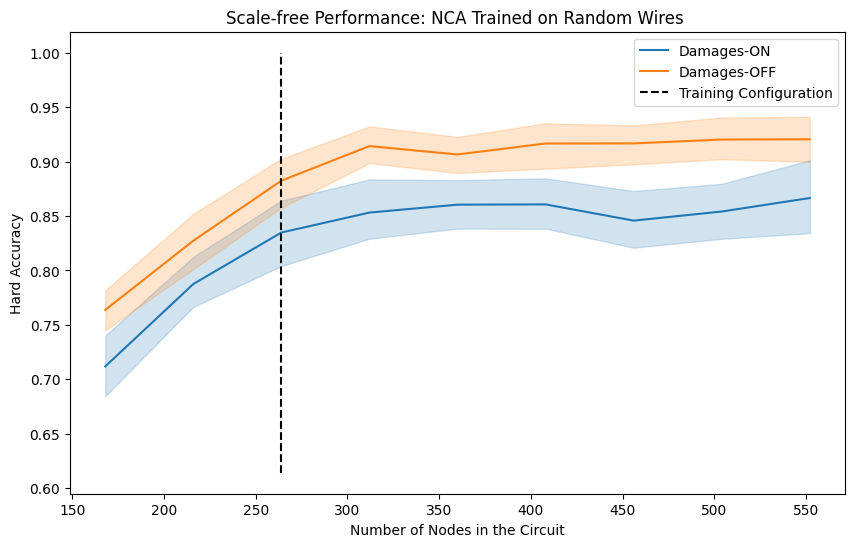

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=scale_free_pd,
    x="n_node",
    y="hard_accuracy",
    hue="dmg_config",
    ax=ax,
)

ax.vlines(
    264,
    scale_free_pd["hard_accuracy"].min(),
    scale_free_pd["hard_accuracy"].max(),
    color="k",
    linestyle="--",
    label="Training Configuration",
)
ax.legend()
ax.set_title("Scale-free Performance: NCA Trained on Random Wires ")
ax.set_xlabel("Number of Nodes in the Circuit")
ax.set_ylabel("Hard Accuracy")
plt.show()


## Sweep Results

In [ ]:
def get_eval_results(run_id, run_bp_baseline=False):

    loaded_config, checkpoint_path, run_id = load_config_from_wandb(
        run_id=run_id,
        entity="gbena",
        filename="best_model_eval",
        use_cache=False,
        # filename="latest_checkpoint",
    )

    case_n = 2**loaded_config.circuit.input_bits
    base_key = jax.random.PRNGKey(loaded_config.seed)

    eval_key = (
        jax.random.fold_in(base_key, 1)
        if not hasattr(loaded_config, "test_seed")
        else jax.random.PRNGKey(loaded_config.test_seed)
    )
    hidden_dim = loaded_config.circuit.circuit_hidden_dim
    input_n, output_n = loaded_config.circuit.input_bits, loaded_config.circuit.output_bits
    arity = loaded_config.circuit.arity
    layer_n = loaded_config.circuit.num_layers

    layer_sizes = generate_layer_sizes(
        input_n, output_n, arity, layer_n=layer_n, width_factor=loaded_config.circuit.width_factor
    )

    if loaded_config.training.wiring_mode == "fixed":
        pool_key = eval_key
    else:
        pool_key = jax.random.fold_in(eval_key, 1)

    wires_key, logits_key = jax.random.split(pool_key, 2)

    batch_size = 16

    pool = initialize_graph_pool(
        wires_key=wires_key,
        logits_key=logits_key,
        pool_size=batch_size,
        layer_sizes=layer_sizes,
        arity=arity,
        input_n=input_n,
        circuit_hidden_dim=hidden_dim,
        wiring_mode=loaded_config.training.wiring_mode,
        # noise_scale=loaded_config.pool.noise_scale,
        noise_scale=0.1,
    )

    print(f"Pool of size {batch_size} initialised ! Circuits are: {pool.graphs.n_node[0]} nodes")

    (x_train, y_train), (x_test, y_test), (x, y0) = get_task_data(
        loaded_config.circuit.task,
        case_n,
        input_bits=loaded_config.circuit.input_bits,
        output_bits=loaded_config.circuit.output_bits,
        text=loaded_config.circuit.text,
        train_test_split=True,
        test_ratio=loaded_config.training.test_num / case_n,
        seed=eval_key,
    )

    damage_params = compute_damage_params(loaded_config, layer_sizes, None)
    n_damage_steps = loaded_config.damage.n_damage_steps
    damage_steps = jp.linspace(0, n_damage_steps, n_damage_steps + 1, endpoint=False).astype(int)[
        1:
    ]
    print(f"Damage steps: {damage_steps}")

    n_steps = loaded_config.eval.inner_steps

    damage_modes = ["none", "probabilistic", "deterministic"]
    permanent_modes = [True]

    # Load model from config and checkpoint
    best_attn_model, _, _ = load_model_from_config_and_checkpoint(
        config=loaded_config,
        checkpoint_path=checkpoint_path,
        run_id=run_id,
        seed=loaded_config.seed,
        n_node=int(pool.graphs.n_node[0].item()),
    )

    attn_eval_results = {
        (damage_mode, permanent): evaluate_model_stepwise_batched(
            model=best_attn_model,
            batch_wires=pool.wires,
            batch_logits=pool.logits,
            x_data=x_test,
            y_data=y_test,
            input_n=input_n,
            arity=arity,
            n_message_steps=n_steps,
            circuit_hidden_dim=hidden_dim,
            loss_cfg=LossConfig(dict(loaded_config.loss)),
            layer_sizes=layer_sizes,
            damage_steps=damage_steps if damage_mode == "deterministic" else None,
            knockout_per_damage_step=damage_params["knockouts_per_event"]
            if damage_mode == "deterministic"
            else None,
            p_fault=damage_params["p_fault_eval"] if damage_mode == "probabilistic" else None,
            bidirectional_edges=True,
            permanent_damage=permanent,
            verbose=True,
            # No-repair baseline
            compute_no_repair_baseline=False,
            p_fault_onset_step=0,
        )
        for damage_mode in damage_modes
        for permanent in permanent_modes
    }

    if run_bp_baseline:
        opt = optax.adamw(1, 0.8, 0.8, weight_decay=1e-1)
        bp_eval_results = {
            (damage_mode, permanent): bp_fn(
                # ── Engine ──
                opt=opt,
                pool=pool,
                # ── Data ──
                x_data=x_train,
                y_data=y_train,
                x_test=x_test,
                y_test=y_test,
                # ── Params ──
                n_steps=n_steps,
                layer_sizes=layer_sizes,
                input_n=input_n,
                arity=arity,
                loss_cfg=LossConfig(loaded_config.loss),
                # ── Damage ──
                p_fault=damage_params["p_fault_eval"] if damage_mode == "probabilistic" else None,
                p_fault_onset_step=0,
                damage_mode="probabilistic" if damage_mode == "probabilistic" else "none",
                damage_steps=damage_steps if damage_mode == "deterministic" else None,
                knockouts_per_event=damage_params["knockouts_per_event"]
                if damage_mode == "deterministic"
                else None,
                faulty_value=damage_params["faulty_logit_value"],
                permanent=permanent,
            )
            for damage_mode in damage_modes
            for permanent in permanent_modes
        }
    else:
        bp_eval_results = {}

    return attn_eval_results, bp_eval_results


In [ ]:
from wandb import Api

# Fixed Wiring Sweep
filters = {"group": "sweep_20260209_231530"}
api = Api()
runs = api.runs("gbena/boolean-nca-cc", filters=filters)
print(f"Found {len(runs)} runs")

Found 30 runs


In [ ]:
all_eval_results = get_eval_results("89jka5qh", run_bp_baseline=False)

2026-02-11 22:09:20,348 - boolean_nca_cc.training.checkpointing - INFO - Looking for run with ID: 89jka5qh
2026-02-11 22:09:20,651 - boolean_nca_cc.training.checkpointing - INFO - Found run: playful-yogurt-965
2026-02-11 22:09:20,652 - boolean_nca_cc.training.checkpointing - INFO - Checking for local checkpoint at: saves/run_89jka5qh/best_model_eval.pkl
2026-02-11 22:09:20,652 - boolean_nca_cc.training.checkpointing - INFO - Cache disabled, downloading from WandB.
2026-02-11 22:09:20,652 - boolean_nca_cc.training.checkpointing - INFO - Retrieving artifacts...
2026-02-11 22:09:20,764 - boolean_nca_cc.training.checkpointing - INFO - Available artifacts:
2026-02-11 22:09:21,125 - boolean_nca_cc.training.checkpointing - INFO -   - latest_checkpoint:v27474
2026-02-11 22:09:21,125 - boolean_nca_cc.training.checkpointing - INFO -   - run-89jka5qh-poolscatter_steps_vs_loss_table-kwUcpA:v6
2026-02-11 22:09:21,125 - boolean_nca_cc.training.checkpointing - INFO -   - run-89jka5qh-poolscatter_dama

Eval key: [ 202567368 3886822060]
Pool of size 16 initialised ! Circuits are: [264] nodes
Damage steps: [0 1]
Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 5],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 264}
Successfully instantiated model: CircuitGatheredAttention
Evaluation complete: 256 steps
  Loss: 0.0004
  Accuracy: 1.0000
  Hard Acc: 1.0000
Evaluation complete: 256 steps
  Loss: 4827.2246
  Accuracy: 0.8434
  Hard Acc: 0.8434
Evaluation complete: 256 steps
  Loss: 2556.3794
  Accuracy: 0.9295
  Hard Acc: 0.9295


In [ ]:
from tqdm.notebook import tqdm

results = []

for run in tqdm(runs, desc="Processing runs"):
    history = run.history()
    run_results = {"run_id": run.id, "run_name": run.name}
    run_results.update(dict(dict(m.split("=") for m in run.metadata["args"])))
    for damage in [True, False]:
        for ood in ["in", "out"]:
            for metric in ["hard_accuracy", "hard_loss", "accuracy", "loss"]:
                for split in ["train", "test"]:
                    key = f"eval_{ood}_{'damaged_' if damage else ''}{split}/final_{metric}"

                    if key in history.columns:
                        run_results[key] = (
                            np.nanmax(history[key].values)
                            if "accuracy" in key
                            else np.nanmin(history[key].values)
                        )

    results.append(run_results)


Processing runs:   0%|          | 0/30 [00:00<?, ?it/s]

### BP baselines

In [ ]:
task_datas = {
    task: get_task_data(
        task,
        case_n,
        input_bits=loaded_config.circuit.input_bits,
        output_bits=loaded_config.circuit.output_bits,
        text=loaded_config.circuit.text,
        train_test_split=True,
        test_ratio=loaded_config.training.test_num / case_n,
        seed=eval_key,
    )
    for task in ["reverse", "add", "binary_multiply"]
}


In [ ]:
batch_size = 16

pool = initialize_graph_pool(
    wires_key=wires_key,
    logits_key=logits_key,
    pool_size=batch_size,
    layer_sizes=layer_sizes,
    arity=arity,
    input_n=input_n,
    circuit_hidden_dim=hidden_dim,
    wiring_mode=loaded_config.training.wiring_mode,
    # noise_scale=loaded_config.pool.noise_scale,
    noise_scale=0.1,
)


In [ ]:
opt = optax.adamw(1, 0.8, 0.8, weight_decay=1e-1)

bp_eval_results = {
    (task, damage): run_bp_scan(
        batch_wires=pool.wires,
        batch_params=pool.logits,
        # ── Engine ──
        opt=opt,
        # ── Data ──
        x_data=task_datas[task][0][0],
        y_data=task_datas[task][0][1],
        x_test=task_datas[task][1][0],
        y_test=task_datas[task][1][1],
        # ── Params ──
        n_steps=n_steps,
        layer_sizes=layer_sizes,
        input_n=input_n,
        arity=arity,
        loss_cfg=LossConfig(loaded_config.loss),
        # ── Damage ──
        p_fault=damage_params["p_fault_eval"] if damage else None,
        p_fault_onset_step=0,
        damage_mode="probabilistic" if damage else "none",
        damage_steps=None,
        knockouts_per_event=None,
        faulty_value=damage_params["faulty_logit_value"],
        permanent=1.0,
    )
    for damage in [True, False]
    for task in ["reverse", "add", "binary_multiply"]
}


Compiling scan+vmap BP (batch=16, steps=256, damage=probabilistic)...
Done.
Final: Loss=9.9539, Acc=1.0000, Hard Acc=1.0000
Compiling scan+vmap BP (batch=16, steps=256, damage=probabilistic)...
Done.
Final: Loss=61.3891, Acc=0.9898, Hard Acc=0.9882
Compiling scan+vmap BP (batch=16, steps=256, damage=probabilistic)...
Done.
Final: Loss=837.8391, Acc=0.8422, Hard Acc=0.8318
Compiling scan+vmap BP (batch=16, steps=256, damage=none)...
Done.
Final: Loss=0.3333, Acc=1.0000, Hard Acc=1.0000
Compiling scan+vmap BP (batch=16, steps=256, damage=none)...
Done.
Final: Loss=27.3111, Acc=0.9955, Hard Acc=0.9950
Compiling scan+vmap BP (batch=16, steps=256, damage=none)...
Done.
Final: Loss=756.0525, Acc=0.8592, Hard Acc=0.8518


### DF and plot

In [ ]:
import pandas as pd

In [ ]:
bp_results = []
for task, damage in bp_eval_results:
    bp_results.append(
        {
            "task": task,
            "damage": damage,
            "hard_accuracy": bp_eval_results[(task, damage)][1]["hard_accuracy"][-1],
            "hard_loss": bp_eval_results[(task, damage)][1]["hard_loss"][-1],
            "accuracy": bp_eval_results[(task, damage)][1]["accuracy"][-1],
            "loss": bp_eval_results[(task, damage)][1]["loss"][-1],
        }
    )


In [ ]:
results_df = pd.DataFrame(results)
results_df.drop(
    columns=[c for c in results_df.columns if not len(results_df[c].unique()) > 1], inplace=True
)
results_df.head()

,run_id,run_name,seed,circuit,damage.enabled,damage.permanent,output.dir,eval_in_test/final_hard_accuracy,eval_in_test/final_hard_loss,eval_in_test/final_accuracy,eval_in_test/final_loss
0,n10gg4bt,radiant-snowflake-924,0,reverse_large,false,false,sweeps/outputs/sweep_20260209_231530/tasks/task_1,1.000000,0.000366,1.000000,0.000366
1,3tjqbmzy,breezy-brook-925,0,reverse_large,true,random,sweeps/outputs/sweep_20260209_231530/tasks/task_2,1.000000,0.000366,1.000000,0.169549
2,1oi6ryce,eternal-night-926,0,add_large,false,false,sweeps/outputs/sweep_20260209_231530/tasks/task_3,0.967773,1588.487549,0.968750,186.114838
3,jw1ll9hm,twilight-glade-927,0,add_large,true,random,sweeps/outputs/sweep_20260209_231530/tasks/task_4,0.933268,3288.571289,0.941081,402.683990
4,igwhllex,sweet-sea-928,0,binary_multiply_large,false,false,sweeps/outputs/sweep_20260209_231530/tasks/task_5,0.819987,8863.756836,0.820638,950.054810


In [ ]:
results_df.rename(columns={"circuit": "Circuit"}, inplace=True)
results_df.rename(columns={"eval_in_test/final_hard_accuracy": "Hard Accuracy"}, inplace=True)
results_df.rename(columns={"damage.enabled": "Damages"}, inplace=True)

In [ ]:
bp_results_df = pd.DataFrame(bp_results)
bp_results_df.head()
bp_results_df.rename(columns={"task": "Circuit"}, inplace=True)
bp_results_df.rename(columns={"damage": "Damages"}, inplace=True)


In [ ]:
circuit_map = {
    "reverse_large": "Bit Reversal",
    "add_large": "Binary Addition",
    "binary_multiply_large": "Binary Multiplication",
    "reverse": "Bit Reversal",
    "add": "Binary Addition",
    "binary_multiply": "Binary Multiplication",
}

results_df["Circuit"] = results_df.apply(
    lambda x: circuit_map.get(x["Circuit"], x["Circuit"]), axis=1, result_type="expand"
)

bp_results_df["Circuit"] = bp_results_df.apply(
    lambda x: circuit_map.get(x["Circuit"], x["Circuit"]), axis=1, result_type="expand"
)

damage_map = {"true": "ON", "false": "OFF", True: "ON", False: "OFF"}
results_df["Damages"] = results_df["Damages"].map(damage_map)

bp_results_df["Damages"] = bp_results_df["Damages"].map(damage_map)


In [ ]:
import seaborn as sns

/home/gb21/miniconda3/envs/nca/lib/python3.13/site-packages/seaborn/categorical.py:2761: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try boxplot
  warnings.warn(msg, UserWarning)


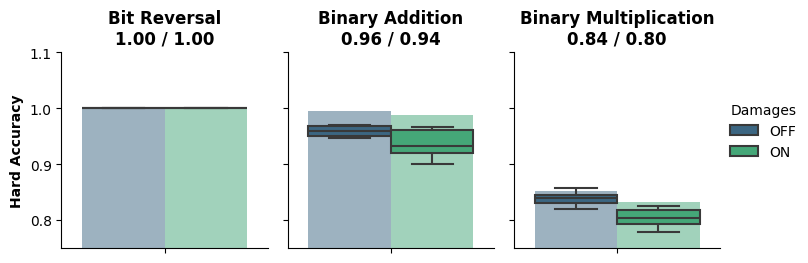

In [ ]:
g = sns.catplot(
    data=results_df,
    col="Circuit",
    y="Hard Accuracy",
    hue="Damages",
    ax=ax,
    palette=sns.color_palette("viridis", 2),
    kind="box",
    aspect=1,
    height=2.5,
    linewidth=1.5,
)


fig = g.figure
axs = g.axes

mean_values = results_df.groupby(["Circuit", "Damages"])["Hard Accuracy"].mean().to_dict()

for ax, task in zip(
    axs.flatten(), ["Bit Reversal", "Binary Addition", "Binary Multiplication"], strict=False
):
    ax.set_title(
        f"{task}\n{mean_values[task, 'OFF']:.2f} / {mean_values[task, 'ON']:.2f}",
        fontweight="bold",
    )
    ax.set_ylim(0.75, 1.1)
    ax.set_ylabel("Hard Accuracy", fontweight="bold")
    sns.barplot(
        data=bp_results_df[bp_results_df["Circuit"] == task],
        # x="damage",
        y="hard_accuracy",
        hue="Damages",
        ax=ax,
        palette=sns.color_palette("viridis", 2),
        alpha=0.5,
        hue_order=["OFF", "ON"],
        legend=False,
    )


plt.savefig("figures/fixed_wiring_nca_hard_accuracy.pdf", dpi=300, bbox_inches="tight")


In [ ]:
fig
fig.savefig("figures/fixed_wiring_nca_hard_accuracy.pdf", dpi=300, bbox_inches="tight")

In [ ]:
mean_values = bp_results_df.groupby(["Circuit", "Damages"])["hard_accuracy"].mean()

In [ ]:
mean_values


In [ ]:
mean_values


In [ ]:
mean_values
